# 05 - XGBoost and SMOTE extension

Huấn luyện XGBoost thường và XGBoost+SMOTE trên split `v2_64_16_20`. SMOTE chỉ được fit trên training set.

In [1]:
from pathlib import Path
import json
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_VERSION = 'v2_64_16_20'
ARTIFACT_VERSION = 'v2_64_16_20_val_split'
processed_path = DATA_DIR / 'processed_split.pkl'
if not processed_path.exists():
    raise FileNotFoundError('Missing data/processed_split.pkl. Run 03_prepare_dataset.ipynb first.')

data = joblib.load(processed_path)
required_keys = {'X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'split_metadata'}
missing_keys = sorted(required_keys - data.keys())
if missing_keys:
    raise KeyError(f'Processed split is missing keys: {missing_keys}. Re-run 03_prepare_dataset.ipynb.')

split_metadata = data['split_metadata']
if split_metadata['split_version'] != SPLIT_VERSION:
    raise ValueError(f"Expected split version {SPLIT_VERSION}; found {split_metadata['split_version']}. Re-run 03_prepare_dataset.ipynb.")

X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']

assert len(X_train) == split_metadata['train_rows']
assert len(X_val) == split_metadata['validation_rows']
assert len(X_test) == split_metadata['test_rows']

print(f"Loaded split: version={split_metadata['split_version']}, generated_at_utc={split_metadata['generated_at_utc']}")
print(f"Split loaded: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

xgb_params = {
    'random_state': 42, 'eval_metric': 'logloss', 'tree_method': 'hist',
    'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'n_jobs': -1,
}


Loaded split: version=v2_64_16_20, generated_at_utc=2026-08-20T09:38:14.782010+00:00
Split loaded: train=(4072076, 15), val=(1018020, 15), test=(1272524, 15)


In [2]:
def evaluate_at_threshold(model, X_eval, y_true, model_name, split_name, train_time_sec, threshold=0.5):
    start = time.perf_counter()
    y_score = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_score >= threshold).astype(int)
    predict_time_sec = time.perf_counter() - start
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'model': model_name, 'evaluation_split': split_name, 'threshold': threshold,
        'accuracy': float((y_pred == y_true.to_numpy()).mean()),
        'precision': float(tp / (tp + fp)) if tp + fp else 0.0,
        'recall': float(tp / (tp + fn)) if tp + fn else 0.0,
        'f1': float(2 * tp / (2 * tp + fp + fn)) if 2 * tp + fp + fn else 0.0,
        'roc_auc': float(roc_auc_score(y_true, y_score)),
        'pr_auc': float(average_precision_score(y_true, y_score)),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'train_time_sec': round(train_time_sec, 3), 'predict_time_sec': round(predict_time_sec, 3),
        'artifact_version': ARTIFACT_VERSION,
    }, y_score, y_pred

def save_confusion_matrix(y_true, y_pred, model_label, filename):
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
    matrix_frame = pd.DataFrame(
        matrix, index=['Actual normal', 'Actual fraud'], columns=['Predicted normal', 'Predicted fraud']
    )
    matrix_frame.to_csv(RESULTS_DIR / f'{filename}_{ARTIFACT_VERSION}.csv')
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(matrix_frame, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Confusion matrix — {model_label} (test, threshold=0.50)')
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('Actual class')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f'{filename}_{ARTIFACT_VERSION}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return matrix_frame


In [3]:
plain_start = time.perf_counter()
xgb_plain = XGBClassifier(**xgb_params)
xgb_plain.fit(X_train, y_train)
xgb_plain_train_time = time.perf_counter() - plain_start

plain_test_metrics, plain_test_score, plain_test_pred = evaluate_at_threshold(
    xgb_plain, X_test, y_test, 'XGBoost (plain)', 'test', xgb_plain_train_time
)
plain_train_metrics, plain_train_score, _ = evaluate_at_threshold(
    xgb_plain, X_train, y_train, 'XGBoost (plain)', 'train_original', xgb_plain_train_time
)
print(pd.Series(plain_test_metrics))


model                     XGBoost (plain)
evaluation_split                     test
threshold                             0.5
accuracy                         0.999996
precision                         0.99939
recall                           0.997565
f1                               0.998477
roc_auc                           0.99998
pr_auc                           0.998772
tn                                1270880
fp                                      1
fn                                      4
tp                                   1639
train_time_sec                     33.899
predict_time_sec                    1.504
artifact_version    v2_64_16_20_val_split
dtype: object


In [4]:
smote = SMOTE(random_state=42)
pre_smote_counts = y_train.value_counts().sort_index()
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
post_smote_counts = pd.Series(y_train_smote).value_counts().sort_index()

smote_summary = pd.DataFrame({
    'class_label': [0, 1],
    'before_smote_train_rows': [int(pre_smote_counts.loc[0]), int(pre_smote_counts.loc[1])],
    'after_smote_train_rows': [int(post_smote_counts.loc[0]), int(post_smote_counts.loc[1])],
    'split_version': SPLIT_VERSION,
    'artifact_version': ARTIFACT_VERSION,
})
smote_summary.to_csv(RESULTS_DIR / f'train_smote_summary_{ARTIFACT_VERSION}.csv', index=False)
print(smote_summary.to_string(index=False))

smote_start = time.perf_counter()
xgb_smote = XGBClassifier(**xgb_params)
xgb_smote.fit(X_train_smote, y_train_smote)
xgb_smote_train_time = time.perf_counter() - smote_start

smote_test_metrics, smote_test_score, smote_test_pred = evaluate_at_threshold(
    xgb_smote, X_test, y_test, 'XGBoost + SMOTE', 'test', xgb_smote_train_time
)
smote_train_metrics, smote_train_score, _ = evaluate_at_threshold(
    xgb_smote, X_train, y_train, 'XGBoost + SMOTE', 'train_original_distribution', xgb_smote_train_time
)
print(pd.Series(smote_test_metrics))


 class_label  before_smote_train_rows  after_smote_train_rows split_version      artifact_version
           0                  4066820                 4066820   v2_64_16_20 v2_64_16_20_val_split
           1                     5256                 4066820   v2_64_16_20 v2_64_16_20_val_split
model                     XGBoost + SMOTE
evaluation_split                     test
threshold                             0.5
accuracy                         0.999896
precision                        0.927077
recall                           0.998174
f1                               0.961313
roc_auc                          0.999741
pr_auc                           0.998576
tn                                1270752
fp                                    129
fn                                      3
tp                                   1640
train_time_sec                     79.013
predict_time_sec                    1.664
artifact_version    v2_64_16_20_val_split
dtype: object


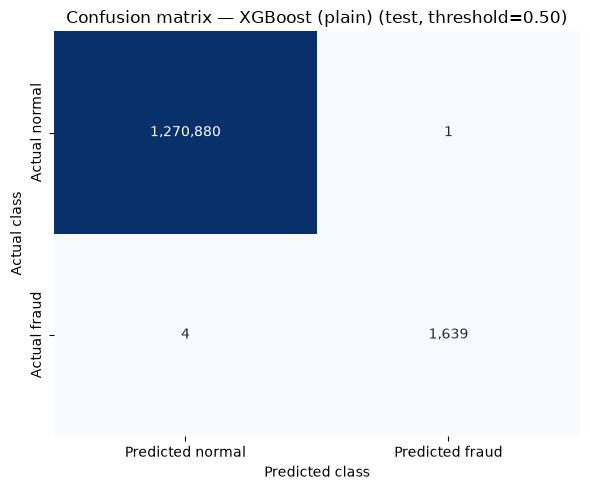

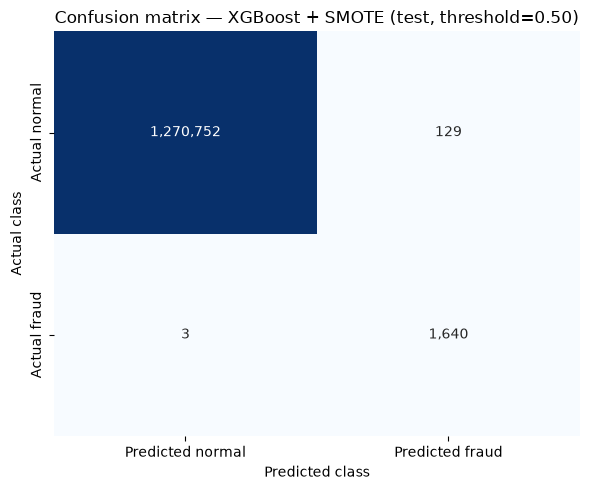

XGBoost plain confusion matrix:
               Predicted normal  Predicted fraud
Actual normal           1270880                1
Actual fraud                  4             1639
XGBoost + SMOTE confusion matrix:
               Predicted normal  Predicted fraud
Actual normal           1270752              129
Actual fraud                  3             1640


In [5]:
plain_confusion = save_confusion_matrix(y_test, plain_test_pred, 'XGBoost (plain)', 'xgb_plain_confusion_matrix')
smote_confusion = save_confusion_matrix(y_test, smote_test_pred, 'XGBoost + SMOTE', 'xgb_smote_confusion_matrix')
print('XGBoost plain confusion matrix:')
print(plain_confusion)
print('XGBoost + SMOTE confusion matrix:')
print(smote_confusion)


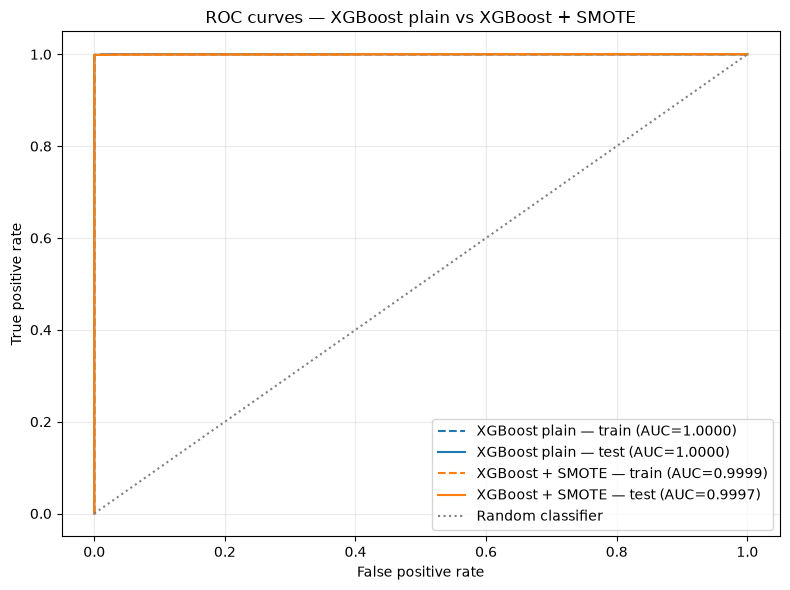

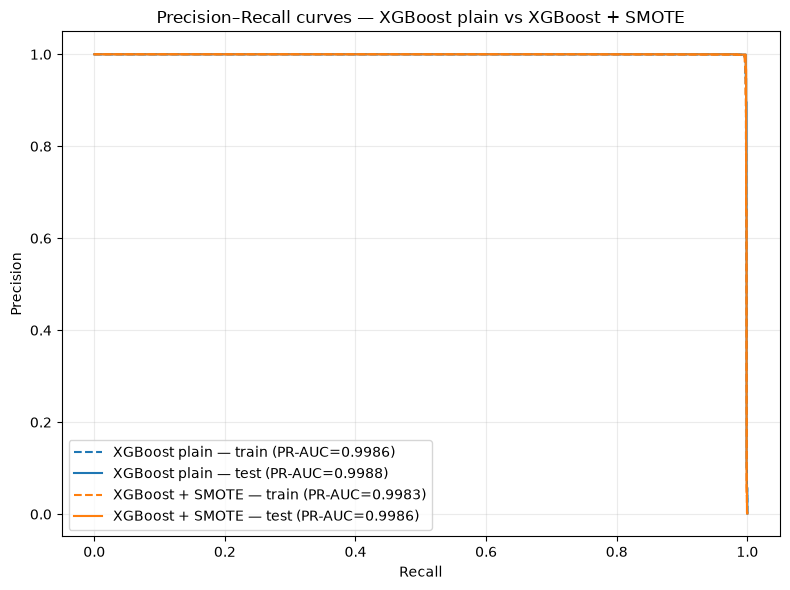

In [6]:
curve_sets = {
    'XGBoost plain — train': (y_train, plain_train_score, 'tab:blue', '--'),
    'XGBoost plain — test': (y_test, plain_test_score, 'tab:blue', '-'),
    'XGBoost + SMOTE — train': (y_train, smote_train_score, 'tab:orange', '--'),
    'XGBoost + SMOTE — test': (y_test, smote_test_score, 'tab:orange', '-'),
}

fig, ax = plt.subplots(figsize=(8, 6))
for label, (y_true, scores, color, line_style) in curve_sets.items():
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)
    ax.plot(fpr, tpr, color=color, linestyle=line_style, label=f'{label} (AUC={auc_value:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle=':', label='Random classifier')
ax.set_title('ROC curves — XGBoost plain vs XGBoost + SMOTE')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'xgb_roc_overlay_{ARTIFACT_VERSION}.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for label, (y_true, scores, color, line_style) in curve_sets.items():
    precision, recall, _ = precision_recall_curve(y_true, scores)
    ap_value = average_precision_score(y_true, scores)
    ax.plot(recall, precision, color=color, linestyle=line_style, label=f'{label} (PR-AUC={ap_value:.4f})')
ax.set_title('Precision–Recall curves — XGBoost plain vs XGBoost + SMOTE')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'xgb_pr_overlay_{ARTIFACT_VERSION}.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
test_comparison = pd.DataFrame([plain_test_metrics, smote_test_metrics])
train_comparison = pd.DataFrame([plain_train_metrics, smote_train_metrics])
test_comparison.to_csv(RESULTS_DIR / f'xgb_test_metrics_{ARTIFACT_VERSION}.csv', index=False)
train_comparison.to_csv(RESULTS_DIR / f'xgb_train_metrics_{ARTIFACT_VERSION}.csv', index=False)

provenance = {
    'artifact_version': ARTIFACT_VERSION,
    'split_metadata': split_metadata,
    'xgb_params': xgb_params,
    'smote_fit_split': 'train_only',
    'test_set_used_for_model_training_or_smote': False,
}
with open(RESULTS_DIR / f'xgb_provenance_{ARTIFACT_VERSION}.json', 'w', encoding='utf-8') as file:
    json.dump(provenance, file, indent=2)

joblib.dump(xgb_plain, RESULTS_DIR / f'xgb_plain_model_{ARTIFACT_VERSION}.pkl')
joblib.dump(xgb_smote, RESULTS_DIR / f'xgb_smote_model_{ARTIFACT_VERSION}.pkl')
joblib.dump({'xgb_plain': xgb_plain, 'xgb_smote': xgb_smote, 'provenance': provenance}, RESULTS_DIR / f'xgb_models_{ARTIFACT_VERSION}.pkl')

print(test_comparison[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'tn', 'fp', 'fn', 'tp']].to_string(index=False))
print(f"Saved versioned XGBoost artifacts with suffix: {ARTIFACT_VERSION}")


          model  accuracy  precision   recall       f1  roc_auc   pr_auc      tn  fp  fn   tp
XGBoost (plain)  0.999996   0.999390 0.997565 0.998477 0.999980 0.998772 1270880   1   4 1639
XGBoost + SMOTE  0.999896   0.927077 0.998174 0.961313 0.999741 0.998576 1270752 129   3 1640
Saved versioned XGBoost artifacts with suffix: v2_64_16_20_val_split


In [8]:
# Final audit: XGBoost / SMOTE experiment on the versioned 64:16:20 split.
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)

def print_test_audit(model, X_eval, y_true, label, threshold=0.5):
    y_score = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_score >= threshold).astype(int)
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = matrix.ravel()

    print(f'\n=== {label} — test (threshold={threshold:.2f}) ===')
    print('Confusion matrix [[TN, FP], [FN, TP]]:')
    print(matrix)
    print(f'TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}')
    print(f'Accuracy:  {accuracy_score(y_true, y_pred):.6f}')
    print(f'Precision: {precision_score(y_true, y_pred, zero_division=0):.6f}')
    print(f'Recall:    {recall_score(y_true, y_pred, zero_division=0):.6f}')
    print(f'F1:        {f1_score(y_true, y_pred, zero_division=0):.6f}')
    print(f'ROC-AUC:   {roc_auc_score(y_true, y_score):.6f}')
    print(f'PR-AUC:    {average_precision_score(y_true, y_score):.6f}')

print('=== XGBoost experiment audit ===')
print(f'Artifact version: {ARTIFACT_VERSION}')
print('Split metadata:', json.dumps(split_metadata, indent=2, default=str))
print(f"Split verification: expected={SPLIT_VERSION}, actual={split_metadata['split_version']}")
print(
    f"Rows — train={len(X_train):,}, validation={len(X_val):,}, test={len(X_test):,}; "
    f"fraud rates — train={y_train.mean():.6%}, validation={y_val.mean():.6%}, test={y_test.mean():.6%}"
)
print('XGBoost parameters:', json.dumps(xgb_params, indent=2, default=str))

before_smote = np.bincount(np.asarray(y_train, dtype=int), minlength=2)
after_smote = np.bincount(np.asarray(y_train_smote, dtype=int), minlength=2)
print('\n=== SMOTE class counts on training set ===')
print(f'Before SMOTE [normal, fraud]: {before_smote.tolist()}')
print(f'After SMOTE  [normal, fraud]: {after_smote.tolist()}')
print(f'SMOTE fit scope: train only; test used for training or SMOTE: {provenance["test_set_used_for_model_training_or_smote"]}')

# Numeric train-test comparison for the plain XGBoost model.
proba_plain_train = xgb_plain.predict_proba(X_train)[:, 1]
proba_plain_test = xgb_plain.predict_proba(X_test)[:, 1]
pred_plain_train = (proba_plain_train >= 0.5).astype(int)
pred_plain_test = (proba_plain_test >= 0.5).astype(int)

def split_metric_summary(split_name, y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'split': split_name,
        'ROC-AUC': roc_auc_score(y_true, y_score),
        'PR-AUC': average_precision_score(y_true, y_score),
        'Precision@0.50': precision_score(y_true, y_pred, zero_division=0),
        'Recall@0.50': recall_score(y_true, y_pred, zero_division=0),
        'F1@0.50': f1_score(y_true, y_pred, zero_division=0),
        'FP': fp,
        'FN': fn,
    }

plain_train_test_comparison = pd.DataFrame([
    split_metric_summary('Train', y_train, pred_plain_train, proba_plain_train),
    split_metric_summary('Test', y_test, pred_plain_test, proba_plain_test),
])
print('\n=== XGBoost (plain): Train vs Test numeric comparison ===')
print(plain_train_test_comparison.to_string(index=False, float_format=lambda value: f'{value:.6f}'))

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, proba_plain_test)
operating_points = []
for fpr_cap in (0.01, 0.025, 0.05):
    valid_indices = np.flatnonzero(fpr_test <= fpr_cap)
    if valid_indices.size:
        index = valid_indices[-1]
        operating_points.append({
            'FPR cap': f'{fpr_cap:.1%}',
            'actual FPR': fpr_test[index],
            'TPR / Recall': tpr_test[index],
            'threshold': thresholds_test[index],
        })

operating_points_frame = pd.DataFrame(operating_points)
print('\n=== XGBoost (plain): Test operating points ===')
print(operating_points_frame.to_string(index=False, float_format=lambda value: f'{value:.6f}'))

print_test_audit(xgb_plain, X_test, y_test, 'XGBoost (plain)')
print_test_audit(xgb_smote, X_test, y_test, 'XGBoost + SMOTE')


=== XGBoost experiment audit ===
Artifact version: v2_64_16_20_val_split
Split metadata: {
  "split_version": "v2_64_16_20",
  "generated_at_utc": "2026-08-20T09:38:14.782010+00:00",
  "random_state": 42,
  "train_fraction": 0.6399998742656328,
  "validation_fraction": 0.16000012573436728,
  "test_fraction": 0.2,
  "train_rows": 4072076,
  "validation_rows": 1018020,
  "test_rows": 1272524,
  "n_features": 15
}
Split verification: expected=v2_64_16_20, actual=v2_64_16_20
Rows — train=4,072,076, validation=1,018,020, test=1,272,524; fraud rates — train=0.129074%, validation=0.129074%, test=0.129113%
XGBoost parameters: {
  "random_state": 42,
  "eval_metric": "logloss",
  "tree_method": "hist",
  "n_estimators": 100,
  "max_depth": 6,
  "learning_rate": 0.1,
  "n_jobs": -1
}

=== SMOTE class counts on training set ===
Before SMOTE [normal, fraud]: [4066820, 5256]
After SMOTE  [normal, fraud]: [4066820, 4066820]
SMOTE fit scope: train only; test used for training or SMOTE: False

=== XGB

=== Operating points (test set), XGBoost plain vs XGBoost + SMOTE ===
          model  fpr_cap fpr_cap_label  actual_fpr  tpr_recall  threshold
XGBoost (plain) 0.010000          1.0%    0.009995    0.998783   0.000053
XGBoost (plain) 0.025000          2.5%    0.024997    1.000000   0.000027
XGBoost (plain) 0.050000          5.0%    0.050000    1.000000   0.000016
XGBoost + SMOTE 0.010000          1.0%    0.009974    0.998783   0.002952
XGBoost + SMOTE 0.025000          2.5%    0.025000    0.998783   0.001319
XGBoost + SMOTE 0.050000          5.0%    0.049921    0.999391   0.000845

Saved: d:\GitHub\fraud-detection-thesis\results\xgb_operating_points_v2_64_16_20_val_split.csv


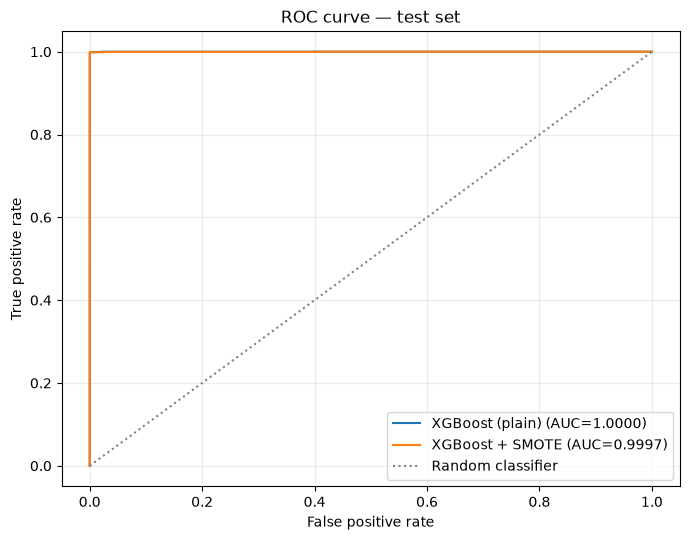

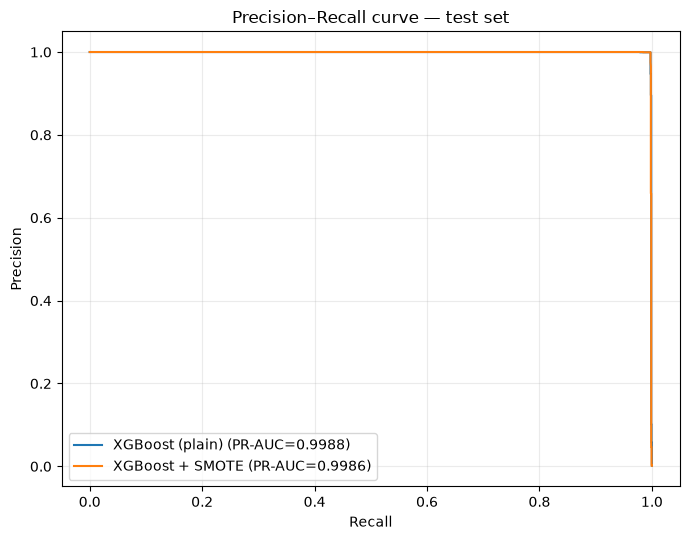

Saved figures: xgb_roc_test_only_v2_64_16_20_val_split.png, xgb_pr_test_only_v2_64_16_20_val_split.png


In [9]:
# === Operating points (FPR caps) cho cả XGBoost plain và XGBoost + SMOTE, lưu ra CSV ===
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

FPR_CAPS = (0.01, 0.025, 0.05)

def operating_points_for_model(y_true, y_score, model_label, fpr_caps=FPR_CAPS):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    rows = []
    for fpr_cap in fpr_caps:
        valid_indices = np.flatnonzero(fpr <= fpr_cap)
        if valid_indices.size:
            index = valid_indices[-1]
            rows.append({
                'model': model_label,
                'fpr_cap': fpr_cap,
                'fpr_cap_label': f'{fpr_cap:.1%}',
                'actual_fpr': fpr[index],
                'tpr_recall': tpr[index],
                'threshold': thresholds[index],
            })
    return rows

operating_points_all = (
    operating_points_for_model(y_test, plain_test_score, 'XGBoost (plain)')
    + operating_points_for_model(y_test, smote_test_score, 'XGBoost + SMOTE')
)
operating_points_frame = pd.DataFrame(operating_points_all)
operating_points_frame.to_csv(RESULTS_DIR / f'xgb_operating_points_{ARTIFACT_VERSION}.csv', index=False)

print('=== Operating points (test set), XGBoost plain vs XGBoost + SMOTE ===')
print(operating_points_frame.to_string(index=False, float_format=lambda v: f'{v:.6f}'))
print(f"\nSaved: {RESULTS_DIR / f'xgb_operating_points_{ARTIFACT_VERSION}.csv'}")


# === Bản ROC / PR rút gọn: chỉ test set, 1 model mỗi loại (dễ chèn vào Hình 4.x/4.y hơn bản overlay 4 đường) ===
test_curve_sets = {
    'XGBoost (plain)': (plain_test_score, 'tab:blue'),
    'XGBoost + SMOTE': (smote_test_score, 'tab:orange'),
}

fig, ax = plt.subplots(figsize=(7, 5.5))
for label, (scores, color) in test_curve_sets.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_value = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, color=color, label=f'{label} (AUC={auc_value:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle=':', label='Random classifier')
ax.set_title('ROC curve — test set')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'xgb_roc_test_only_{ARTIFACT_VERSION}.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 5.5))
for label, (scores, color) in test_curve_sets.items():
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ap_value = average_precision_score(y_test, scores)
    ax.plot(recall, precision, color=color, label=f'{label} (PR-AUC={ap_value:.4f})')
ax.set_title('Precision–Recall curve — test set')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'xgb_pr_test_only_{ARTIFACT_VERSION}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved figures: xgb_roc_test_only_{ARTIFACT_VERSION}.png, xgb_pr_test_only_{ARTIFACT_VERSION}.png")

=== XGBoost + SMOTE — Train vs Test metrics ===
           evaluation_split  accuracy  precision   recall       f1  roc_auc   pr_auc      tn  fp  fn   tp
train_original_distribution  0.999877   0.915299 0.997146 0.954471 0.999863 0.998327 4066335 485  15 5241
                       test  0.999896   0.927077 0.998174 0.961313 0.999741 0.998576 1270752 129   3 1640


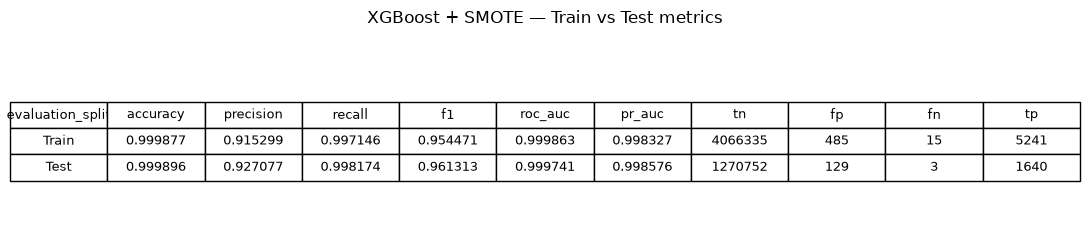


Saved: results/xgb_smote_train_test_metrics_v2_64_16_20_val_split.csv
Saved: reports/figures/xgb_smote_train_test_metrics_v2_64_16_20_val_split.png


In [ ]:
# === Bảng train/test metrics riêng cho XGBoost + SMOTE (tách khỏi bảng gộp) ===
smote_test_row = test_comparison[test_comparison['model'] == 'XGBoost + SMOTE'].copy()
smote_train_row = train_comparison[train_comparison['model'] == 'XGBoost + SMOTE'].copy()

smote_train_test_metrics = pd.concat([smote_train_row, smote_test_row], ignore_index=True)
smote_train_test_metrics.to_csv(
    RESULTS_DIR / f'xgb_smote_train_test_metrics_{ARTIFACT_VERSION}.csv', index=False
)
print('=== XGBoost + SMOTE — Train vs Test metrics ===')
print(
    smote_train_test_metrics[
        ['evaluation_split', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'tn', 'fp', 'fn', 'tp']
    ].to_string(index=False, float_format=lambda v: f'{v:.6f}')
)

# Render thành ảnh bảng (dễ chèn thẳng vào Word/luận văn như 1 Hình/Bảng riêng)
display_cols = ['evaluation_split', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'tn', 'fp', 'fn', 'tp']
display_frame = smote_train_test_metrics[display_cols].round(6)
display_frame['evaluation_split'] = display_frame['evaluation_split'].replace({
    'train_original_distribution': 'Train',
    'test': 'Test',
})

fig, ax = plt.subplots(figsize=(11, 1.6 + 0.5 * len(display_frame)))
ax.axis('off')
table = ax.table(
    cellText=display_frame.values,
    colLabels=display_frame.columns,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)
ax.set_title('XGBoost + SMOTE — Train vs Test metrics', pad=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'xgb_smote_train_test_metrics_{ARTIFACT_VERSION}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved: results/xgb_smote_train_test_metrics_{ARTIFACT_VERSION}.csv")
print(f"Saved: reports/figures/xgb_smote_train_test_metrics_{ARTIFACT_VERSION}.png")